In [9]:
#7.1

import numpy as np
from numpy import linalg as la

A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
det = la.det(A)

b = np.array([2,2,-1])
inv = la.inv(A)
xyz = inv@b
print(f'x, y, z = {xyz}')
print()

tran = A.T
print(A@tran)   #not orthogonal
print()

lam, v = la.eig(A)
print(f'eigenvalues = {lam}')

x, y, z = [10. -1. -2.]

[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]

eigenvalues = [ 1.         -4.79128785 -0.20871215]


In [26]:
#7.3

import numpy as np
from numpy import linalg as la
from math import cos, sin, radians

def Ex(angle):
    ang = radians(angle)
    ex = np.array([1,0,0,0,cos(ang),sin(ang),0,-sin(ang),cos(ang)])
    ex = ex.reshape(3,3)
    return ex

def Ey(angle):
    ang = radians(angle)
    ey = np.array([cos(ang),0,-sin(ang),0,1,0,sin(ang),0,cos(ang)])
    ey = ey.reshape(3,3)
    return ey
    
def Ez(angle):
    ang = radians(angle)
    ez = np.array([cos(ang),sin(ang),0,-sin(ang),cos(ang),0,0,0,1])
    ez = ez.reshape(3,3)
    return ez

E = Ez(57)@Ey(62.6)@Ez(192.25)
print(E)
print()

A = np.array([1,0,0])
rot = E@A
print(rot)   #???
print()

lam, v = la.eig(E)
print(lam.reshape(3,1))
print()

ra = radians(192.25)
dec = radians(27.4)

r = np.array([cos(dec)*cos(ra),cos(dec)*sin(ra),sin(dec)]).reshape(3,1)
print(r)
norm = la.norm(r)
print(f'norm = {norm}')
print()

rot2 = E@r
print(rot2.round())

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]

[-0.06698874  0.49272847 -0.86760081]

[[-0.52856796+0.84889099j]
 [-0.52856796-0.84889099j]
 [ 1.        +0.j        ]]

[[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]
norm = 1.0

[[0.]
 [0.]
 [1.]]


coefficients = [[ 2.18582332e+02]
 [-5.51003145e+02]
 [ 5.65812236e+02]
 [-3.13633555e+02]
 [ 1.04544074e+02]
 [-2.19331359e+01]
 [ 2.91867714e+00]
 [-2.39059755e-01]
 [ 1.09925609e-02]
 [-2.17117476e-04]]


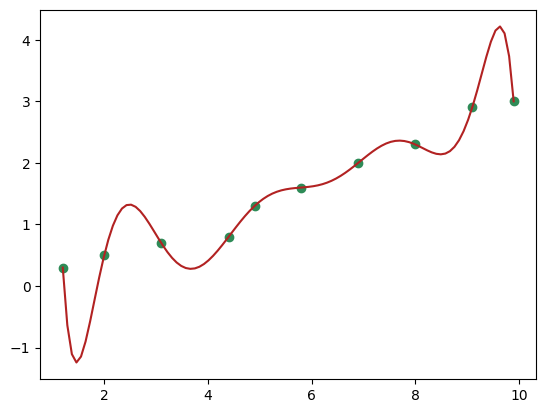

In [62]:
#7.5

import numpy as np
from numpy import linalg as la
from matplotlib.pyplot import figure, show

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

n = len(x)
A = np.array([])
for i in range(n):
    X = x[i]
    B = np.array([])
    for j in range(n):
        b = X**j
        B = np.append(B,b)
    A = np.append(A,B)
    
A = A.reshape(n,n)
y = y.reshape(n,1)

a = la.solve(A,y)
print(f'coefficients = {a}')

fig = figure()
frame = fig.add_subplot()
frame.scatter(x,y,color='seagreen')

xval = np.linspace(min(x),max(x),100)
yval = np.array([])
c = 0
for i in range(len(a)):
    c += a[i]*(xval**i)

yval = np.append(yval,c)

frame.plot(xval,yval,color='firebrick')

show()

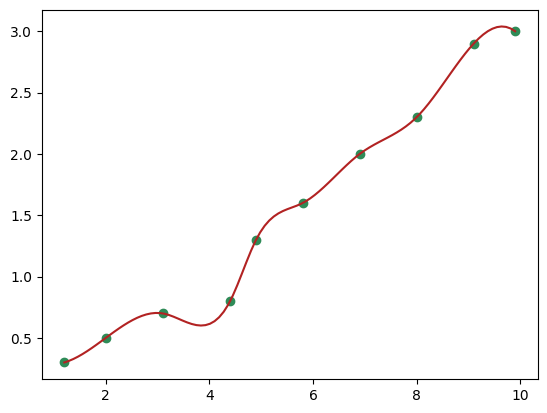

In [68]:
#7.6

import numpy as np
from numpy import linalg as la
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

f = ip.interp1d(x, y, kind='cubic')

fig = figure()
frame = fig.add_subplot()
frame.scatter(x,y,color='seagreen')

xval = np.linspace(1.2,9.9,100)
yval = f(xval)

frame.plot(xval,yval,color='firebrick')

show()

In [ ]:
class Interpolation:
    def __init__(self,x,y):
        self.x = x
        self.y = y
        
    def linear():
        f = ip.interp1d(x, y, kind='linear')
        return f
    
    def linear():
        f = ip.interp1d(x, y, kind='linear')
        return f